# Regression Metrics: A Deep Dive

Once a regression model is trained, we need to evaluate how well it is performing. In this notebook, we will explore the mathematical intuition and code implementations for:
- **MAE** (Mean Absolute Error)
- **MSE** (Mean Squared Error)
- **RMSE** (Root Mean Squared Error)
- **$R^2$ Score** (Coefficient of Determination)
- **Adjusted $R^2$ Score**

**Why do we need 5 different metrics?**
No single metric is perfect! Some are easy to interpret for humans, some are mathematically robust to outliers, some are perfectly shaped for algorithms to optimize, and others allow us to compare models across entirely different datasets. Below, we break down the **Advantages** and **Disadvantages** of each so you know exactly when to use them.

Finally, we will demonstrate the fundamental difference between $R^2$ and Adjusted $R^2$ by adding irrelevant and relevant features to our dataset.

## 1. The Dataset & Initial Setup

Let's load the `Placement.csv` dataset, which contains `cgpa` and `package`, and train a baseline Simple Linear Regression model.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("Placement.csv")

# Original features and target
X = df[['cgpa']]
y = df['package']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Train Baseline Model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Make predictions for evaluation
y_pred = lr.predict(X_test)

print("Baseline Model Trained Successfully!")
display(df.head())

Baseline Model Trained Successfully!


,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


## 2. Mean Absolute Error (MAE)

**Intuition:** MAE measures the average magnitude of errors in a set of predictions, without considering their direction.

**Mathematics:**
$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

- $y_i$ = Actual value
- $\hat{y}_i$ = Predicted value
- $n$ = Number of observations

**✅ Advantages:**
- **Intuitive:** The error is in the exact same units as the target variable (e.g., if predicting LPA, an MAE of 1.5 means you are off by 1.5 LPA on average). This is very easy to explain to non-technical stakeholders.
- **Robust to Outliers:** It does not heavily penalize large errors, making it a good choice if your dataset has noisy outlier data that you don't want to dominate the metric.

**❌ Disadvantages:**
- **Not easily differentiable:** The absolute value function is not differentiable at zero, which makes it computationally harder to use directly as a loss function for gradient descent algorithms.

In [39]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 0.2884710931878175


## 3. Mean Squared Error (MSE)

**Intuition:** MSE measures the average of the squares of the errors.

**Mathematics:**
$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

**✅ Advantages:**
- **Differentiable:** The squared function yields a smooth, continuous gradient. This makes it incredibly easy and efficient to optimize using Gradient Descent (which is why it's the default loss function for many ML algorithms).
- **Penalizes large errors:** By squaring the error, a mistake of 10 units is penalized 100 times more than a mistake of 1 unit. This forces the model to focus on reducing its most massive errors.

**❌ Disadvantages:**
- **Sensitive to Outliers:** Because large errors are squared, a single massive outlier in your data can artificially inflate the MSE and make a decent model look mathematically terrible.
- **Loss of original units:** If your target is in 'LPA', your MSE is in 'LPA squared'. This makes no intuitive business sense to a human reader.

In [40]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.12129235313495527


## 4. Root Mean Squared Error (RMSE)

**Intuition:** RMSE is simply the square root of MSE. It acts as a bridge between the mathematical benefits of MSE and the interpretability of MAE.

**Mathematics:**
$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

**✅ Advantages:**
- **Interpretable Units:** Taking the square root brings the metric back to the original units of the target variable, solving the biggest problem of MSE.
- **Penalizes large errors:** Like MSE, it still heavily penalizes large prediction failures, which is great if you are predicting something where huge mistakes are dangerous (like stock prices or healthcare metrics).

**❌ Disadvantages:**
- **Still sensitive to outliers:** While slightly better than raw MSE, it is still much more impacted by outliers compared to MAE.

In [41]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 0.34827051717731616


## 5. R-squared ($R^2$) Score

**Intuition:** $R^2$ represents the proportion of variance in the dependent variable that is explained by the linear model. An $R^2$ of 1.0 means perfect predictions.

**Mathematics:**
$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$
*(Where the numerator is the sum of squared errors, and the denominator is the total sum of squares).*

**✅ Advantages:**
- **Scale-Free:** It gives a score usually between 0 and 1, making it incredibly easy to compare how well models perform across entirely different datasets. (You can't do this with MAE/RMSE, because those depend on the target's numerical scale).
- **Clear baseline:** An $R^2$ of 0 simply means the model is performing exactly as well as a 'dumb' model that just guesses the mean of the data every single time.

**❌ Disadvantages:**
- **The "More is Better" Illusion:** $R^2$ will *never decrease* when you add new features to your model. Even if you add completely random, useless columns (like the phase of the moon to predict salary), $R^2$ will stay the same or go up slightly by pure chance. This can trick you into overfitting your model with too many features.

In [42]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.780730147510384


## 6. Adjusted R-squared Score

**Intuition:** The problem with $R^2$ is that it *never decreases* when you add new features. Adjusted $R^2$ solves this by **penalizing** the model for adding useless features.

**Mathematics:**
$$
R^2_{adj} = 1 - \frac{(1 - R^2)(n - 1)}{n - k - 1}
$$
- $R^2$ = Normal R-squared score
- $n$ = Number of observations
- $k$ = Number of predictor variables (features)

**✅ Advantages:**
- **Penalizes Irrelevant Features:** It actively punishes the score if you add a feature that doesn't significantly improve the model's predictions. 
- **Perfect for Multiple Regression:** It is the golden standard for evaluating models with multiple input features because it balances model complexity with accuracy.

**❌ Disadvantages:**
- **Doesn't give absolute error:** Like regular $R^2$, it only tells you the *proportion* of variance explained. It doesn't tell you by how many LPA your salary prediction is actually off. (This is exactly why you always pair $R^2_{adj}$ with MAE or RMSE!)

In [43]:
n = X_test.shape[0]
k = X_test.shape[1]
adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print("Adjusted R2 Score:", adj_r2)

Adjusted R2 Score: 0.7749598882343415


---
## 7. The Problem with $R^2$: Adding an Irrelevant Feature

Let's add a completely random column to our dataset. 
Because the linear regression model will try to find *some* tiny correlation by chance, the **$R^2$ score will usually go up slightly (or stay the same)**. However, the **Adjusted $R^2$ score will decrease**, correctly penalizing us for making the model more complex with no real predictive power.

In [44]:
# Add a random feature
df_random = df.copy()
df_random['random_feature'] = np.random.rand(len(df))

X_rand = df_random[['cgpa', 'random_feature']]
y_rand = df_random['package']

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_rand, y_rand, test_size=0.2, random_state=2)

lr_rand = LinearRegression()
lr_rand.fit(Xr_train, yr_train)
yr_pred = lr_rand.predict(Xr_test)

r2_rand = r2_score(yr_test, yr_pred)
n_r = Xr_test.shape[0]
k_r = Xr_test.shape[1]
adj_r2_rand = 1 - ((1 - r2_rand) * (n_r - 1) / (n_r - k_r - 1))

print("--- WITH RANDOM FEATURE ---")
print("Old R2:", r2, " | New R2:", r2_rand)
print("Old Adj R2:", adj_r2, " | New Adj R2:", adj_r2_rand)

--- WITH RANDOM FEATURE ---
Old R2: 0.780730147510384  | New R2: 0.7819026188084681
Old Adj R2: 0.7749598882343415  | New Adj R2: 0.7701135711764935


---
## 8. The Solution: Adding a Relevant Feature ('iq')

Now let's add a feature that is actually correlated with the target (Package). We will create a synthetic `iq` column. 
Because this feature adds real predictive value, **both $R^2$ and Adjusted $R^2$ will increase significantly** (moving closer to 1.0).

In [45]:
# Add a relevant feature 'iq' (Let's assume IQ is highly correlated with the package)
df_iq = df.copy()
# Creating a synthetic 'iq' column that has some linear relationship with 'package'
df_iq['iq'] = df_iq['package'] * 25 + np.random.normal(0, 5, size=len(df))

X_iq = df_iq[['cgpa', 'iq']]
y_iq = df_iq['package']

Xiq_train, Xiq_test, yiq_train, yiq_test = train_test_split(X_iq, y_iq, test_size=0.2, random_state=2)

lr_iq = LinearRegression()
lr_iq.fit(Xiq_train, yiq_train)
yiq_pred = lr_iq.predict(Xiq_test)

r2_iq = r2_score(yiq_test, yiq_pred)
n_iq = Xiq_test.shape[0]
k_iq = Xiq_test.shape[1]
adj_r2_iq = 1 - ((1 - r2_iq) * (n_iq - 1) / (n_iq - k_iq - 1))

print("--- WITH RELEVANT FEATURE (IQ) ---")
print("Old R2:", r2, " | New R2 (IQ):", r2_iq)
print("Old Adj R2:", adj_r2, " | New Adj R2 (IQ):", adj_r2_iq)

--- WITH RELEVANT FEATURE (IQ) ---
Old R2: 0.780730147510384  | New R2 (IQ): 0.9226788313654616
Old Adj R2: 0.7749598882343415  | New Adj R2 (IQ): 0.9184993087365676


## 9. Visualizing the Metric Changes

Let's plot the differences to intuitively see how $R^2$ vs Adjusted $R^2$ react to adding features.

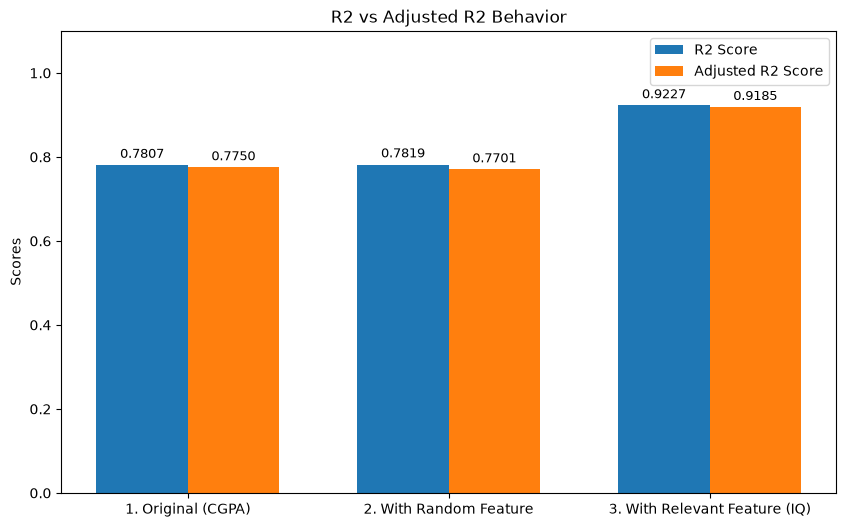

In [46]:
labels = ['1. Original (CGPA)', '2. With Random Feature', '3. With Relevant Feature (IQ)']
r2_scores = [r2, r2_rand, r2_iq]
adj_r2_scores = [adj_r2, adj_r2_rand, adj_r2_iq]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, r2_scores, width, label='R2 Score', color='#1f77b4')
rects2 = ax.bar(x + width/2, adj_r2_scores, width, label='Adjusted R2 Score', color='#ff7f0e')

ax.set_ylabel('Scores')
ax.set_title('R2 vs Adjusted R2 Behavior')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add score values on top of bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.ylim(0, 1.1)  # Expand y-axis slightly for annotations
plt.show()